# Molecular interactions in 1BRS

This notebook demonstrates typed contact analysis with `biotools.structure.contacts`
and the associated 2D and 3D plots, using the
[barnase–barstar complex 1BRS](https://www.rcsb.org/structure/1BRS).
From the three copies in the crystal, we select partner chains **A** (barnase)
and **D** (barstar), including their assigned water residues.

**Requirements:** Install `biotools` before running this notebook.
The structure is downloaded from the Protein Data Bank.
Contact detection uses the built-in `templates` topology backend;
OpenMM and MSMS are not required. The interactive 3D view loads 3Dmol.js
from the internet.

In [1]:
from collections import Counter
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt

from biotools.structure import (
    extract_chain,
    get_pdb_structure,
    plot_interaction_matrix,
    plot_interchain_distance_matrix,
    plot_interchain_interaction_matrix,
    plot_structure_contacts,
)
from biotools.structure.contacts import (
    aggregate_contact_features,
    analyze_contacts,
    prepare_contact_system,
)

## Load the structure and select chains

`extract_chain` creates a copy containing chains A and D. Their assigned
crystal waters are retained for water-bridge detection.

In [2]:
with TemporaryDirectory(prefix="biotools-1brs-") as download_dir:
    full_structure = get_pdb_structure(
        "1brs", target_folder=download_dir, verbose=False
    )

structure = extract_chain(full_structure, ("A", "D"), verbose=False)
print("PDB:", structure.id)
print("Chains:", [chain.id for chain in structure[0]])
print("Atoms:", sum(1 for _ in structure.get_atoms()))

PDB: 1brs
Chains: ['A', 'D']
Atoms: 1779


## Calculate typed contacts

`prepare_contact_system` checks the partners, topology, and water sites.
`analyze_contacts` returns `ContactObservation` objects with stable atom
references, partner roles, geometry measurements, and diagnostics.

The dense van der Waals contact layer is omitted here. Set
`van_der_waals_contact=True` to include it.
1BRS has no explicit hydrogen atoms, so directional hydrogen bonds may be
underdetected. The corresponding diagnostic is printed below.

In [3]:
system = prepare_contact_system(
    structure, partners=("A", "D"), topology_backend="templates"
)
contact_result = analyze_contacts(
    system, profile="refined", van_der_waals_contact=False
)

print("Detected contacts:", len(contact_result.observations))
print("Coverage:", dict(contact_result.coverage))
for diagnostic in contact_result.diagnostics:
    print(f"{diagnostic.severity}: {diagnostic.code} – {diagnostic.message}")

Detected contacts: 26
Coverage: {'protein_residues': 195, 'water_sites': 222, 'atoms': 1779, 'heavy_atoms': 1779, 'explicit_hydrogens': 0, 'unsupported_residues': 0, 'observations': 26}


In [4]:
counts = Counter(
    observation.interaction_type
    for observation in contact_result.observations
)
for interaction_type, number in sorted(counts.items()):
    print(f"{interaction_type:28s} {number:3d}")

example = next(
    (item for item in contact_result.observations
     if item.interaction_type == "salt_bridge"),
    None,
)
if example is not None:
    print()
    print("Example typed contact:")
    print("Type:", example.interaction_type)
    print("Partner A:", [(atom.chain_id, atom.residue_name, atom.residue_number, atom.atom_name) for atom in example.partner_a])
    print("Partner B:", [(atom.chain_id, atom.residue_name, atom.residue_number, atom.atom_name) for atom in example.partner_b])
    print("Geometry:", example.geometry)

cation_pi_candidate            1
hydrophobic_contact            9
pi_stacking_t_shaped           1
salt_bridge                    3
water_bridge                  12

Example typed contact:
Type: salt_bridge
Partner A: [('A', 'ARG', 59, 'CZ'), ('A', 'ARG', 59, 'NH1'), ('A', 'ARG', 59, 'NH2')]
Partner B: [('D', 'GLU', 76, 'OE1'), ('D', 'GLU', 76, 'OE2')]
Geometry: (GeometryMeasurement(name='charge_center_distance', value=3.3858450092580314, unit='angstrom'), GeometryMeasurement(name='nearest_group_atom_distance', value=2.9652259825546796, unit='angstrom'))


## Aggregate contacts

Aggregation summarizes contact counts and distances while preserving
the underlying observations for detailed views.

In [5]:
features = aggregate_contact_features(contact_result)
for name, value in sorted(features.features.items()):
    print(f"{name:48s} {value:.2f}")

cation_pi_candidate.distance_max                 4.14
cation_pi_candidate.distance_median              4.14
cation_pi_candidate.distance_min                 4.14
cation_pi_candidate.observation_count            1.00
hydrophobic_contact.distance_max                 3.96
hydrophobic_contact.distance_median              3.82
hydrophobic_contact.distance_min                 3.54
hydrophobic_contact.observation_count            9.00
pi_stacking_t_shaped.distance_max                3.55
pi_stacking_t_shaped.distance_median             3.55
pi_stacking_t_shaped.distance_min                3.55
pi_stacking_t_shaped.observation_count           1.00
salt_bridge.distance_max                         2.97
salt_bridge.distance_median                      2.93
salt_bridge.distance_min                         2.50
salt_bridge.observation_count                    3.00
water_bridge.distance_max                        3.03
water_bridge.distance_median                     2.72
water_bridge.distance_min   

## 2D plots: distances and interaction types

The matrix functions calculate their inputs directly from the structure;
they do not automatically reuse `contact_result`. The first plot shows
minimum heavy-atom distances, and the second shows interaction classes
between barnase and barstar. The intrachain matrix below illustrates
salt bridges within barnase.

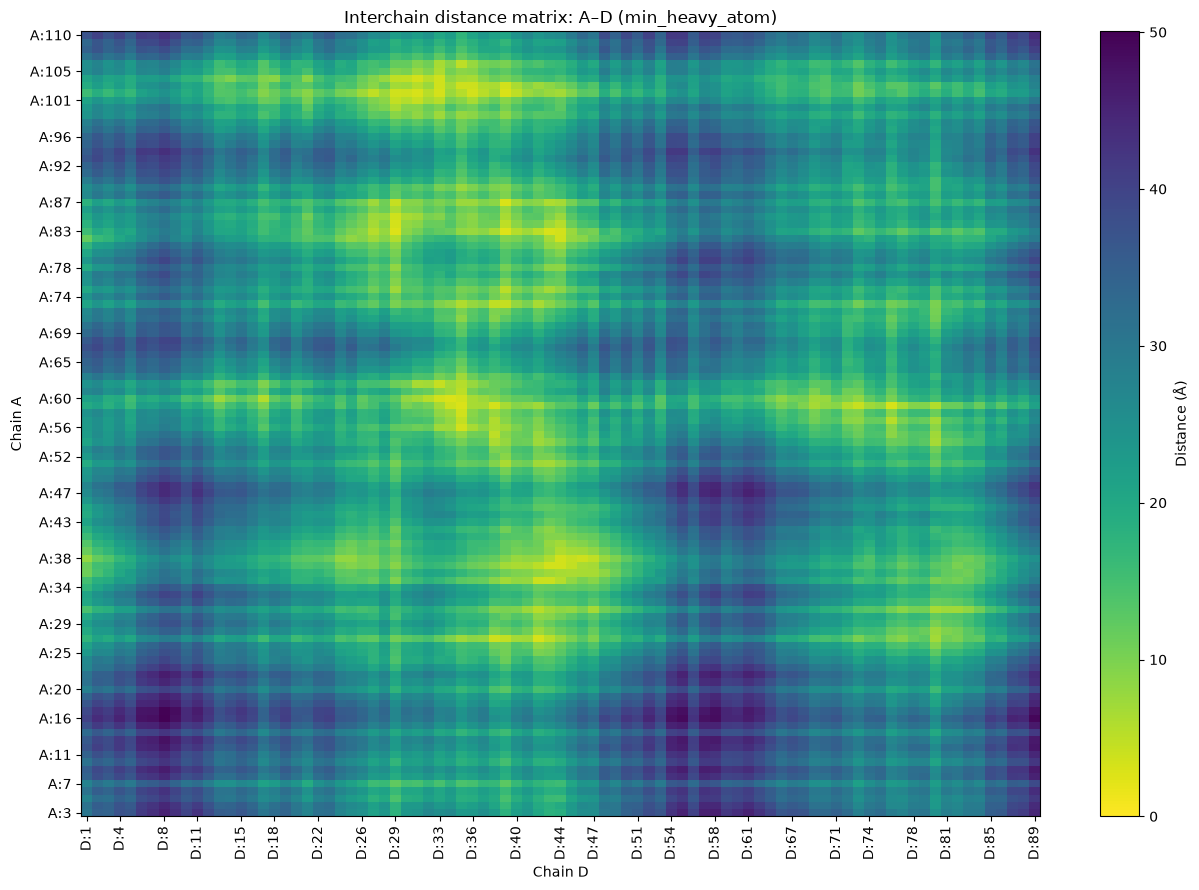

In [6]:
fig, ax = plot_interchain_distance_matrix(
    structure, "A", "D", distance_metric="min_heavy_atom"
)
fig.set_size_inches(13, 9)
fig.tight_layout()
plt.show()

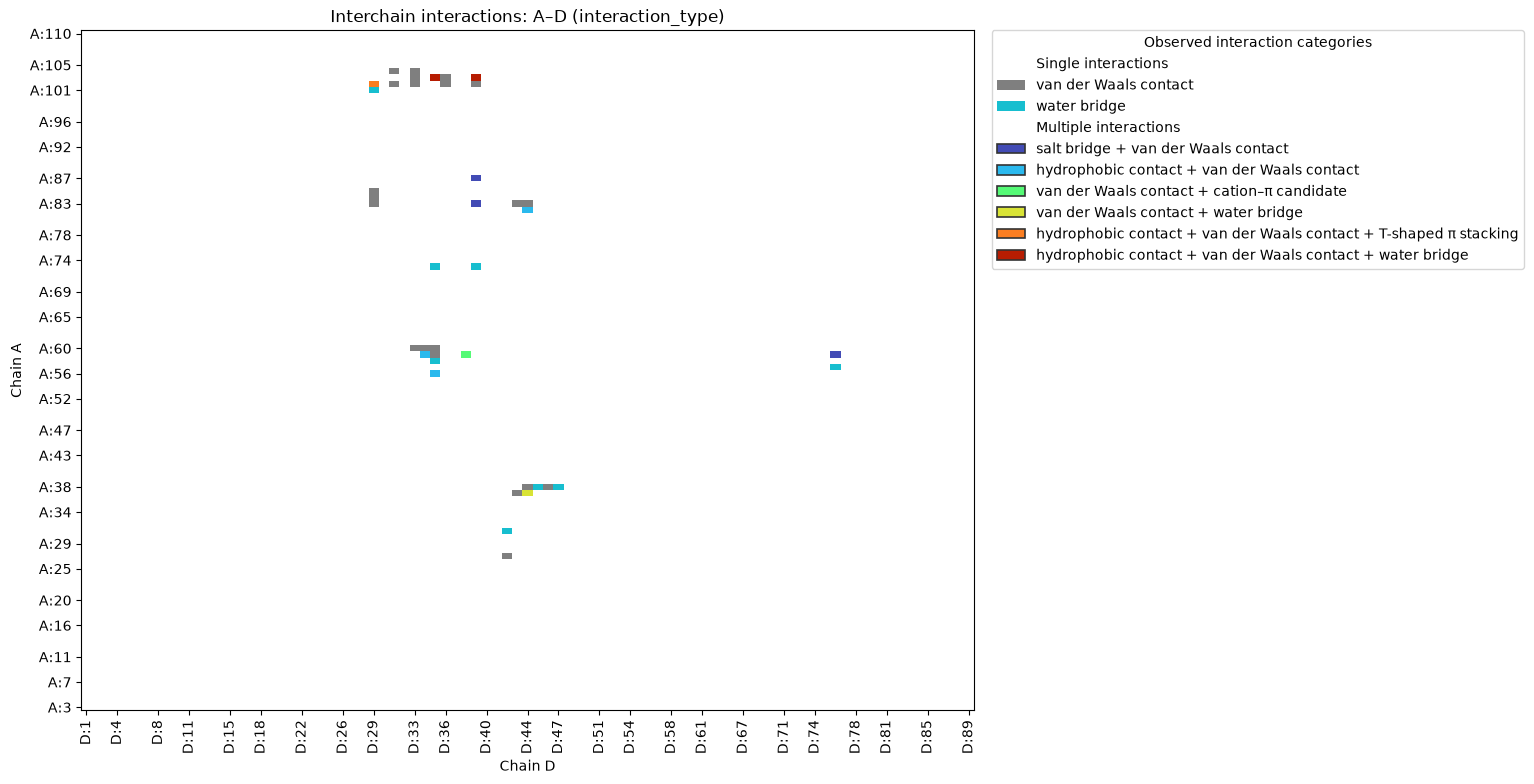

In [7]:
fig, ax = plot_interchain_interaction_matrix(
    structure, "A", "D", interaction_measure="interaction_type",
    topology_backend="templates",
)
fig.set_size_inches(15, 10)
fig.subplots_adjust(right=0.72, bottom=0.20)
plt.show()

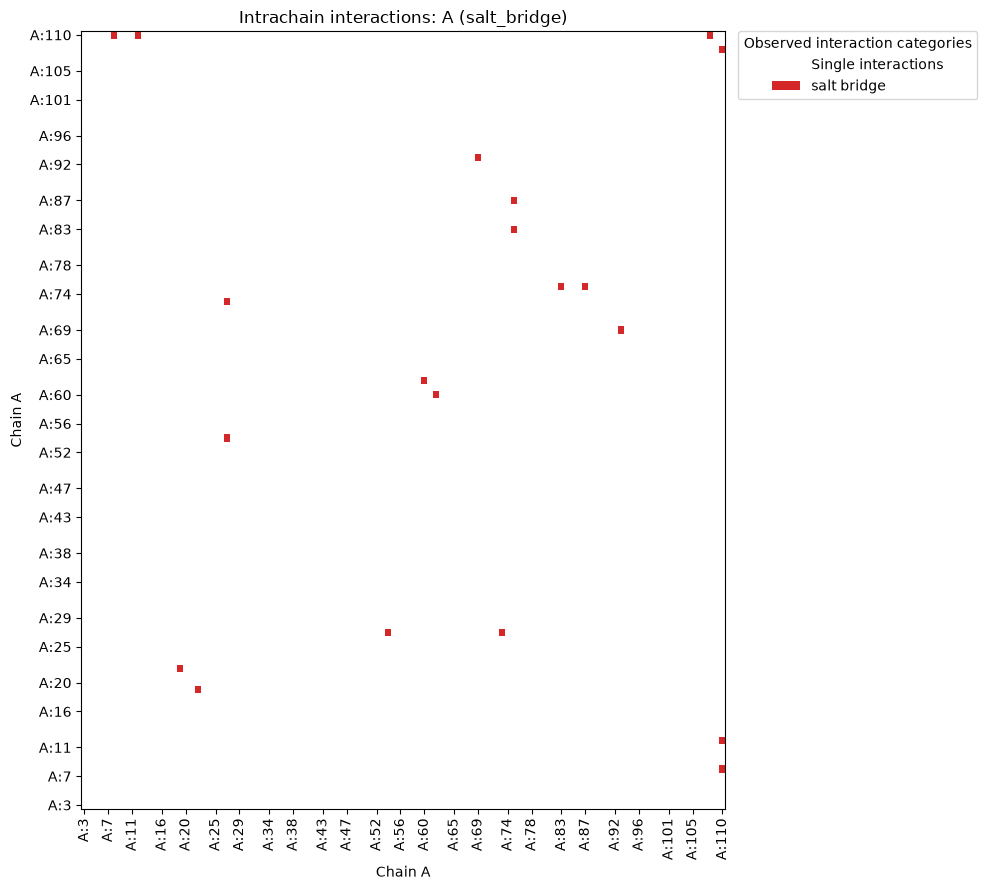

In [8]:
fig, ax = plot_interaction_matrix(
    structure, "A", interaction_measure="salt_bridge",
    topology_backend="templates",
)
fig.set_size_inches(10, 9)
fig.tight_layout()
plt.show()

## Interactive 3D contact view

`plot_structure_contacts` uses the existing `contact_result`.
`contact_types` selects which types are included in the HTML document.
`enabled_contact_types` only sets their initial visibility: hydrophobic
contacts can still be enabled from the sidebar.

**Views** are at the top, followed by **Residue labels** and **Interaction types**.
Use **Show … contacts** to expand a type. Each row identifies the chain,
residue, position, and distance. The checkbox controls visibility; the
**Highlight** toggle adds or removes a floating label independently for
each contact. Multiple visible contacts can be highlighted together.

Residues participating in visible contacts are also drawn as sticks
(enabled by default). The sticks disappear when the last visible
contact involving that residue is hidden. Rotate and zoom in the 3D window,
or choose the `xy`, `xz`, and `yz` view presets.

In [9]:
chain_styles = {
    "A": {"cartoon": {"color": "#c8cdd1", "opacity": 0.62}},
    "D": {"cartoon": {"color": "#d97721", "opacity": 0.88}},
}
chain_labels = {"A": "Barnase", "D": "Barstar"}

contact_view = plot_structure_contacts(
    structure,
    contact_result,
    chain_styles=chain_styles,
    chain_labels=chain_labels,
    contact_types={
        "salt_bridge",
        "hydrophobic_contact",
        "water_bridge",
        "pi_stacking_t_shaped",
        "cation_pi_candidate",
    },
    enabled_contact_types={
        "salt_bridge",
        "water_bridge",
        "pi_stacking_t_shaped",
        "cation_pi_candidate",
    },
    residue_labels={"A": "active", "D": "active"},
    residue_label_universe="contact_residues",
    initial_view="xy",
    width=1050,
    height=680,
)
contact_view

## Filter types and highlight multiple pairs

This second view includes salt bridges and water bridges.
The next cell restricts it to two salt-bridge pairs and highlights both.
`show_contact_pairs` excludes other pairs from the exported document;
`set_contact_pair_enabled` only changes visibility.
Use `set_contact_pair_highlighted(pair_id, False)` to remove a single
highlight while keeping its contact visible, or `clear_highlight()` to
remove all highlights.

In [10]:
focused_view = plot_structure_contacts(
    structure,
    contact_result,
    chain_styles=chain_styles,
    chain_labels=chain_labels,
    contact_types={"salt_bridge", "water_bridge"},
    enabled_contact_types={"salt_bridge"},
    residue_labels={"A": "active", "D": "active"},
    residue_label_universe="contact_residues",
    width=900,
    height=600,
)
focused_view

In [11]:
pairs = [
    item for item in focused_view.contacts
    if item.interaction_type == "salt_bridge"
][:2]
focused_view.show_contact_pairs({pair.pair_id for pair in pairs})
focused_view.set_all_contacts_enabled(True)
for pair in pairs:
    focused_view.highlight_contact_pair(pair.pair_id)

print("Highlighted pairs:", sorted(focused_view.highlighted_pair_ids))
print("Contacts included:", len(focused_view.contacts))
print("Active residues:", sorted(focused_view.active_residues))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Highlighted pairs: ['pair-2b6c29ce33ae-1', 'pair-953ed0a922c7-1']
Contacts included: 2
Active residues: [('A', '', 59, ''), ('A', '', 83, ''), ('D', '', 39, ''), ('D', '', 76, '')]


## Export interactive HTML

The file contains the structure, selected contact geometry, and the same
controls as the notebook. An internet connection is required to load
3Dmol.js when opening it.

In [12]:
html_path = focused_view.write_html(Path("1brs_contacts.html"))
print("Saved:", html_path.resolve())

Saved: /home/lorenz/Environments/biotools/examples/1brs_contacts.html
